In [ ]:
# !pip install gurobipy networkx matplotlib

In [5]:
import os
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB



Restricted license - for non-production use only - expires 2027-11-29
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 9 7940HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
MIPGap  0

Optimize a model with 462 rows, 55 columns and 1303 nonzeros (Min)
Model fingerprint: 0x8f11d61c
Model has 10 linear objective coefficients
Variable types: 0 continuous, 55 integer (55 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Found heuristic solution: objective 3.0000000
Presolve time: 0.00s
Presolved: 462 rows, 55 columns, 1303 nonzeros
Variable types: 0 continuous, 55 integer (55 binary)

Root relaxation: objective 0.000000e+00, 31 iterations, 0.00 seconds (0.00 work unit

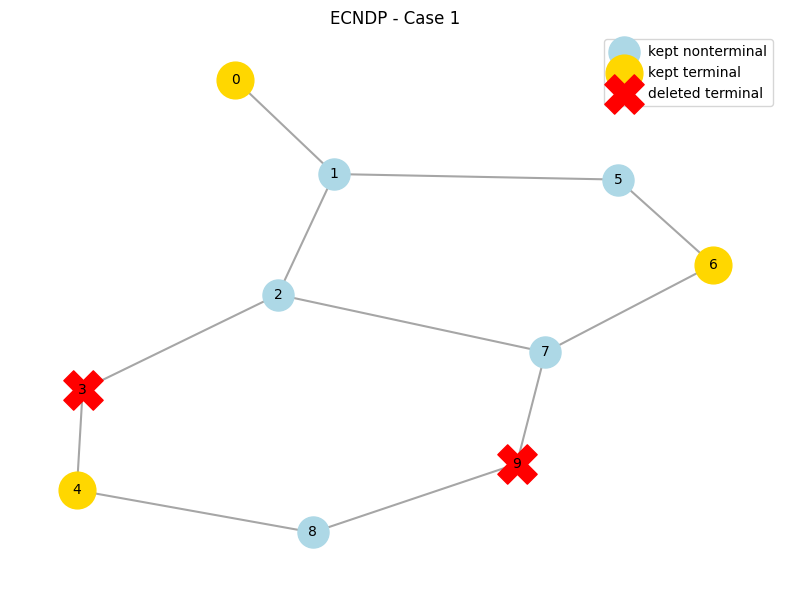

Restricted license - for non-production use only - expires 2027-11-29
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 9 7940HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
MIPGap  0

Optimize a model with 467 rows, 55 columns and 1303 nonzeros (Min)
Model fingerprint: 0x5c9045a1
Model has 10 linear objective coefficients
Variable types: 0 continuous, 55 integer (55 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Found heuristic solution: objective 10.0000000
Presolve removed 227 rows and 21 columns
Presolve time: 0.00s
Presolved: 240 rows, 34 columns, 648 nonzeros
Variable types: 0 continuous, 34 integer (34 binary)

Root relaxation: objective 3.000000e+00, 24

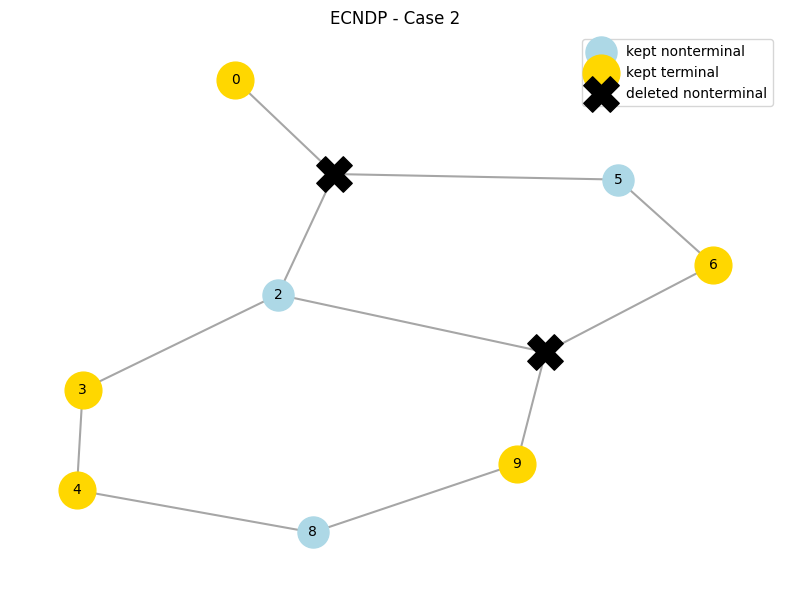

In [6]:
LICENSE_PATH = r"C:\Users\billi\Downloads\gurobi.lic"


def status_to_string(status_code):
    mapping = {
        GRB.LOADED: "LOADED",
        GRB.OPTIMAL: "OPTIMAL",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.UNBOUNDED: "UNBOUNDED",
        GRB.CUTOFF: "CUTOFF",
        GRB.ITERATION_LIMIT: "ITERATION_LIMIT",
        GRB.NODE_LIMIT: "NODE_LIMIT",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.SOLUTION_LIMIT: "SOLUTION_LIMIT",
        GRB.INTERRUPTED: "INTERRUPTED",
        GRB.NUMERIC: "NUMERIC",
        GRB.SUBOPTIMAL: "SUBOPTIMAL",
        GRB.USER_OBJ_LIMIT: "USER_OBJ_LIMIT",
    }
    return mapping.get(status_code, f"UNKNOWN_{status_code}")


def solve_ecndp_gurobi(
    G,
    terminals,
    K,
    case=1,
    license_path=LICENSE_PATH,
    time_limit=None,
    mip_gap=0.0,
    threads=None,
    verbose=True,
):

    if license_path:
        os.environ["GRB_LICENSE_FILE"] = license_path

    if not isinstance(G, nx.Graph) or G.is_directed():
        raise ValueError("G must be an undirected networkx.Graph")

    V = sorted(G.nodes())
    Vset = set(V)
    T = set(terminals)

    if not T.issubset(Vset):
        raise ValueError("terminals must be a subset of graph nodes")

    if case not in (1, 2):
        raise ValueError("case must be 1 or 2")

    if K < 0:
        raise ValueError("K must be nonnegative")

    nonterminals = sorted(Vset - T)

    if case == 1 and K > len(V):
        raise ValueError("For case 1, K cannot exceed |V|")
    if case == 2 and K > len(nonterminals):
        raise ValueError("For case 2, K cannot exceed |V \\ T|")

    pairs = list(itertools.combinations(V, 2))
    terminal_pairs = [(i, j) for (i, j) in pairs if i in T and j in T]
    triples = list(itertools.combinations(V, 3))
    edges = [tuple(sorted(e)) for e in G.edges()]

    env = gp.Env(empty=True)
    if not verbose:
        env.setParam("OutputFlag", 0)
    env.start()

    model = gp.Model("ECNDP", env=env)

    # Variables
    s = model.addVars(V, vtype=GRB.BINARY, name="s")
    x = model.addVars(pairs, vtype=GRB.BINARY, name="x")

    # Objective
    model.setObjective(
        gp.quicksum(x[i, j] for (i, j) in terminal_pairs),
        GRB.MINIMIZE
    )

    # Budget / terminal protection
    if case == 1:
        model.addConstr(gp.quicksum(s[i] for i in V) <= K, name="budget")
    else:
        model.addConstr(gp.quicksum(s[i] for i in nonterminals) <= K, name="budget")
        for t in T:
            model.addConstr(s[t] == 0, name=f"protect_{t}")

    # Surviving adjacent vertices must be connected
    for (i, j) in edges:
        model.addConstr(x[i, j] >= 1 - s[i] - s[j], name=f"edge_{i}_{j}")

    # Deleted vertices cannot be connected to any other vertex
    for (i, j) in pairs:
        model.addConstr(x[i, j] <= 1 - s[i], name=f"up1_{i}_{j}")
        model.addConstr(x[i, j] <= 1 - s[j], name=f"up2_{i}_{j}")

    # Triangle inequalities
    for (i, j, k) in triples:
        model.addConstr(x[i, j] + x[j, k] - x[i, k] <= 1, name=f"tri1_{i}_{j}_{k}")
        model.addConstr(x[i, j] + x[i, k] - x[j, k] <= 1, name=f"tri2_{i}_{j}_{k}")
        model.addConstr(x[i, k] + x[j, k] - x[i, j] <= 1, name=f"tri3_{i}_{j}_{k}")

    # Parameters
    model.Params.MIPGap = float(mip_gap)
    if time_limit is not None:
        model.Params.TimeLimit = float(time_limit)
    if threads is not None:
        model.Params.Threads = int(threads)

    model.optimize()

    status = model.Status
    has_solution = model.SolCount > 0

    if not has_solution:
        return {
            "status_code": status,
            "status": status_to_string(status),
            "objective": None,
            "best_bound": None,
            "deleted": None,
            "kept": None,
            "connected_terminal_pairs": None,
            "terminal_components": None,
            "model": model,
        }

    deleted = sorted(i for i in V if s[i].X > 0.5)
    kept = sorted(i for i in V if s[i].X <= 0.5)
    connected_terminal_pairs = sorted(
        (i, j) for (i, j) in terminal_pairs if x[i, j].X > 0.5
    )

    residual = G.subgraph(kept).copy()
    comps = list(nx.connected_components(residual))

    terminal_components = []
    for comp in comps:
        comp_terminals = sorted(set(comp) & T)
        if comp_terminals:
            terminal_components.append(comp_terminals)

    return {
        "status_code": status,
        "status": status_to_string(status),
        "objective": model.ObjVal,
        "best_bound": model.ObjBound,
        "deleted": deleted,
        "kept": kept,
        "connected_terminal_pairs": connected_terminal_pairs,
        "terminal_components": terminal_components,
        "model": model,
    }


def draw_solution(G, terminals, deleted, title=None, seed=7):
    
    T = set(terminals)
    D = set(deleted)
    K = set(G.nodes()) - D

    surviving_terminals = sorted(T & K)
    surviving_nonterminals = sorted(K - T)
    deleted_terminals = sorted(T & D)
    deleted_nonterminals = sorted(D - T)

    pos = nx.spring_layout(G, seed=seed)

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.5)

    if surviving_nonterminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=surviving_nonterminals,
            node_size=500,
            node_color="lightblue",
            label="kept nonterminal"
        )

    if surviving_terminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=surviving_terminals,
            node_size=700,
            node_color="gold",
            label="kept terminal"
        )

    if deleted_nonterminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=deleted_nonterminals,
            node_size=650,
            node_color="black",
            node_shape="X",
            label="deleted nonterminal"
        )

    if deleted_terminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=deleted_terminals,
            node_size=800,
            node_color="red",
            node_shape="X",
            label="deleted terminal"
        )

    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title(title or "ECNDP solution")
    plt.axis("off")
    plt.legend()
    plt.tight_layout()
    plt.show()


def build_example_graph():
    G = nx.Graph()
    G.add_edges_from([
        (0, 1), (1, 2), (2, 3), (3, 4),
        (1, 5), (5, 6), (6, 7), (2, 7),
        (4, 8), (8, 9), (7, 9)
    ])
    terminals = {0, 3, 4, 6, 9}
    return G, terminals


if __name__ == "__main__":
    G, terminals = build_example_graph()
    K = 2

    # Case 1: terminals may be deleted
    result1 = solve_ecndp_gurobi(
        G=G,
        terminals=terminals,
        K=K,
        case=1,
        license_path=LICENSE_PATH,
        time_limit=None,
        mip_gap=0.0,
        threads=None,
        verbose=True,
    )

    print("\n=== CASE 1: terminals may be deleted ===")
    print("Status:", result1["status"])
    print("Objective:", result1["objective"])
    print("Best bound:", result1["best_bound"])
    print("Deleted nodes:", result1["deleted"])
    print("Connected terminal pairs:", result1["connected_terminal_pairs"])
    print("Terminal components:", result1["terminal_components"])

    if result1["deleted"] is not None:
        draw_solution(G, terminals, result1["deleted"], title="ECNDP - Case 1")

    # Case 2: terminals cannot be deleted
    result2 = solve_ecndp_gurobi(
        G=G,
        terminals=terminals,
        K=K,
        case=2,
        license_path=LICENSE_PATH,
        time_limit=None,
        mip_gap=0.0,
        threads=None,
        verbose=True,
    )

    print("\n=== CASE 2: terminals cannot be deleted ===")
    print("Status:", result2["status"])
    print("Objective:", result2["objective"])
    print("Best bound:", result2["best_bound"])
    print("Deleted nodes:", result2["deleted"])
    print("Connected terminal pairs:", result2["connected_terminal_pairs"])
    print("Terminal components:", result2["terminal_components"])

    if result2["deleted"] is not None:
        draw_solution(G, terminals, result2["deleted"], title="ECNDP - Case 2")